## Phase 2 baseline: LightGBM

Walks through `src/models/baseline_lightgbm.py` step by step, reusing its
actual functions (and the logistic regression baseline's data-loading /
feature-selection helpers) rather than re-deriving the logic here, so this
notebook stays tied to the reviewed/tested scripts instead of drifting into
its own copy.

Goal: understand *what changes (and what doesn't) when swapping a linear
model for gradient boosted trees on the same data* - no changes to the
train/val split, features, or evaluation happen here. See
`docs/concepts_log.md`'s 2026-09-17 entries for the full gradient boosting
and class-imbalance explanations.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "src"))

from models.baseline_logistic_regression import (
    BINARY_COLS,
    CONTINUOUS_COLS,
    FEATURE_COLS,
    load_train_val,
    prepare_features,
    top_k_lift,
)
from models.baseline_lightgbm import evaluate, fit_baseline, print_feature_importance

import lightgbm as lgb

### Load train + val

Test stays untouched until the final reported number
(`docs/decisions/004-three-way-split.md`) - this baseline is fit on train and
sanity-checked on val only, same as the logistic regression baseline.

In [2]:
df = load_train_val()

by_split = df.groupby("split")["adoption"].agg(["size", "mean"])
by_split = by_split.rename(columns={"size": "rows", "mean": "adoption_rate"})
by_split

,rows,adoption_rate
split,,
train,7694326,0.006329
val,1751740,0.00438


### Feature set

The exact same 16 Phase 2 engineered features as the logistic regression
baseline, on purpose - keeping the feature set identical isolates the effect
of the model architecture (linear vs. tree ensemble) rather than mixing in a
feature-engineering difference too.

In [3]:
print(f"{len(CONTINUOUS_COLS)} continuous:", CONTINUOUS_COLS)
print(f"{len(BINARY_COLS)} binary/one-hot:", BINARY_COLS)

6 continuous: ['tenure_months', 'activity_index', 'product_count_prev', 'age_years', 'age_years_sq', 'renta_log']
12 binary/one-hot: ['tenure_missing', 'activity_missing', 'product_count_missing', 'age_missing', 'sexo_h', 'sexo_v', 'sexo_missing', 'segmento_top', 'segmento_particulares', 'segmento_universitario', 'segmento_missing', 'renta_missing']


### Prepare features and target

No scaling step here, unlike the LR notebook - tree splits are invariant to
monotonic transforms of a feature, so raw values work exactly as well as
standardized ones. `prepare_features` (imported from the LR baseline module)
still handles selecting the feature matrix and casting the nullable
`adoption` boolean to a plain int.

In [4]:
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]

X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)

print(f"train: {X_train.shape}, adoption rate {y_train.mean():.3%}")
print(f"val:   {X_val.shape}, adoption rate {y_val.mean():.3%}")

train: (7694326, 18), adoption rate 0.633%
val:   (1751740, 18), adoption rate 0.438%


### A real finding: class reweighting broke early stopping

The logistic regression baseline needed `class_weight="balanced"` to learn
anything useful from a ~0.6%-positive dataset. The natural instinct is to
reach for LightGBM's equivalent, `is_unbalance=True`. Doing that here first
actually made things *worse*: early stopping (`stopping_rounds=20` on val
AUC) triggered almost immediately, because the inflated gradient on the rare
class made val AUC swing sharply round to round instead of trending, so an
early round looked like a local peak before boosting could build a real
ensemble. Unlike logistic regression's one-shot convex optimization,
boosting corrects errors incrementally across rounds, and reweighting
amplifies each round's correction enough to destabilize that process.

Below: fitting both ways side by side on the real data, comparing
`best_iteration_` (how many boosting rounds actually ran before early
stopping declared a winner).

In [5]:
model_unbalanced = lgb.LGBMClassifier(
    objective="binary", is_unbalance=True, n_estimators=500, random_state=42, verbosity=-1,
)
model_unbalanced.fit(
    X_train, y_train, eval_X=X_val, eval_y=y_val, eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
)

model_plain = fit_baseline(X_train, y_train, X_val, y_val)

print(f"is_unbalance=True -> best_iteration_ = {model_unbalanced.best_iteration_}")
print(f"no reweighting     -> best_iteration_ = {model_plain.best_iteration_}")

for name, m in [("is_unbalance=True", model_unbalanced), ("no reweighting", model_plain)]:
    scores = m.predict_proba(X_val)[:, 1]
    print(f"{name}: val ROC-AUC={roc_auc_score(y_val, scores):.4f}, "
          f"top-1% lift={top_k_lift(y_val, scores):.2f}x")

is_unbalance=True -> best_iteration_ = 1
no reweighting     -> best_iteration_ = 36


is_unbalance=True: val ROC-AUC=0.9158, top-1% lift=13.32x


no reweighting: val ROC-AUC=0.9198, top-1% lift=17.13x


Dropping the reweighting lets boosting actually run and scores better on
every metric - trees pick splits by information gain, which naturally finds
a rare class's distinguishing features without needing every row reweighted
first, unlike a single global linear decision boundary. `model_plain` above
is exactly what `fit_baseline` (the real baseline function) produces, so the
rest of this notebook continues with it.

### Evaluate: ROC-AUC and top-1% lift

Same two metrics as the LR notebook, for direct comparison. **ROC-AUC**
answers: if you picked one random adopter and one random non-adopter, how
often does the model score the adopter higher? **Top-1% lift**: among the 1%
of customers scored highest, how much higher is the actual adoption rate
than the population average.

In [6]:
model = model_plain

evaluate(model, X_train, y_train, "train")
evaluate(model, X_val, y_val, "val")

train: ROC-AUC=0.9148, top-1% lift=14.75x, n=7,694,326, adoption_rate=0.633%


val: ROC-AUC=0.9198, top-1% lift=17.13x, n=1,751,740, adoption_rate=0.438%


### ROC curve

Same shape of curve as the LR notebook - true positive rate vs. false
positive rate as the decision threshold sweeps from 1 to 0. A curve bowing
further toward the top-left corner than LR's means better separation.

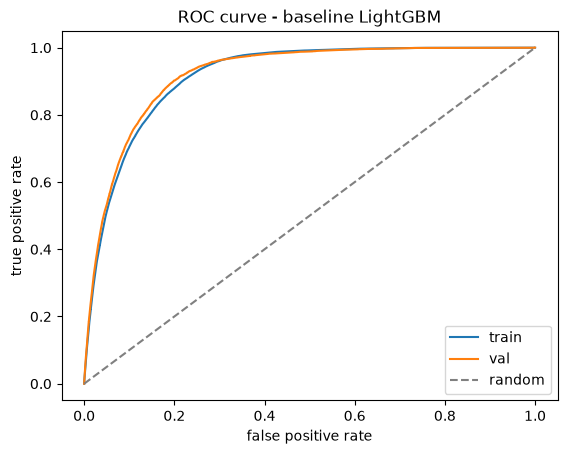

In [7]:
fig, ax = plt.subplots()
for X, y, label in [(X_train, y_train, "train"), (X_val, y_val, "val")]:
    scores = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, scores)
    ax.plot(fpr, tpr, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="random")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve - baseline LightGBM")
ax.legend()
plt.show()

### Predicted probability distribution by actual outcome (val)

If the model is separating the classes, adopters' predicted probabilities
should sit meaningfully to the right of non-adopters', even though both
distributions overlap somewhat - adoption is a fundamentally noisy event,
not a deterministic one.

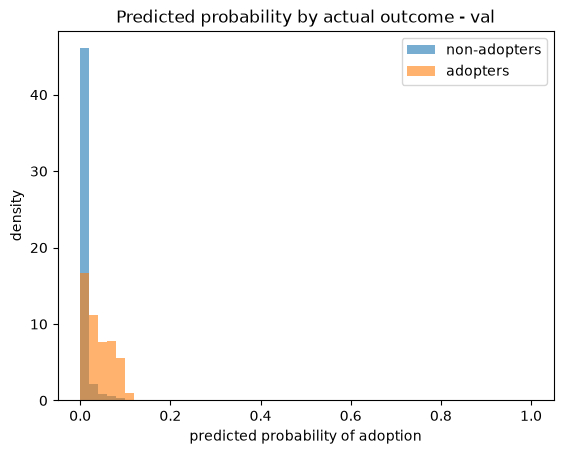

In [8]:
val_scores = model.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots()
ax.hist(val_scores[y_val == 0], bins=50, alpha=0.6, label="non-adopters", density=True)
ax.hist(val_scores[y_val == 1], bins=50, alpha=0.6, label="adopters", density=True)
ax.set_xlabel("predicted probability of adoption")
ax.set_ylabel("density")
ax.set_title("Predicted probability by actual outcome - val")
ax.legend()
plt.show()

### Feature importance

Unlike LR's coefficients (one number per feature, on a shared log-odds
scale), LightGBM's `feature_importances_` counts how many times each
feature was actually used as a split point across every tree in the
ensemble - a feature with 0 importance was never useful enough to split on
in this run.


feature importance (split count, sorted):
age_years                 292
tenure_months             256
product_count_prev        180
renta_log                 145
activity_index             56
sexo_h                     31
sexo_v                     31
age_years_sq               27
segmento_particulares      18
segmento_universitario     16
segmento_top               12
renta_missing               8
segmento_missing            4
age_missing                 4
product_count_missing       0
activity_missing            0
tenure_missing              0
sexo_missing                0


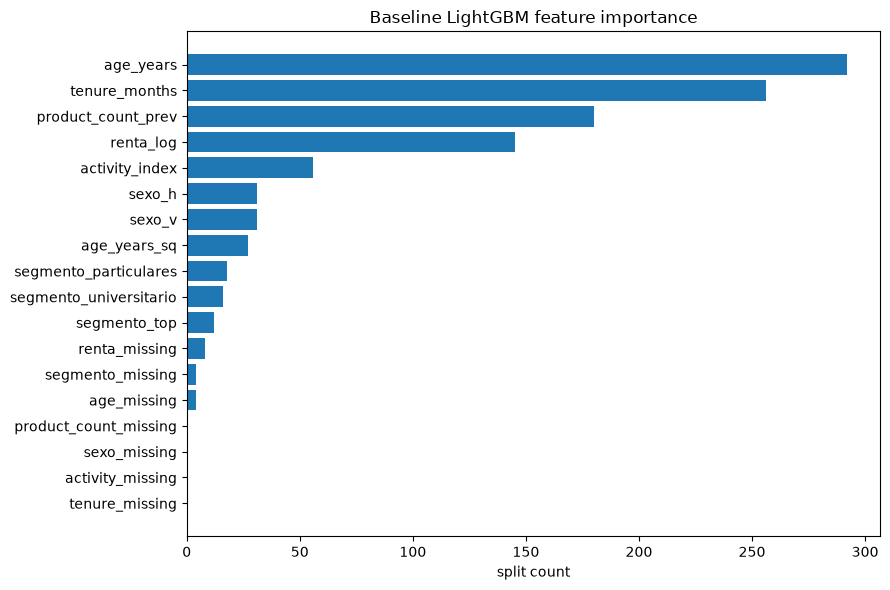

In [9]:
print_feature_importance(model)

importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance.index, importance.values, color="#1f77b4")
ax.set_xlabel("split count")
ax.set_title("Baseline LightGBM feature importance")
plt.tight_layout()
plt.show()

### Lift across different contact budgets (val)

Sweeping `top_k_lift` across a few budget sizes shows how lift decays as the
contact list grows - the same view the LR notebook built, so the two curves
can be compared directly.

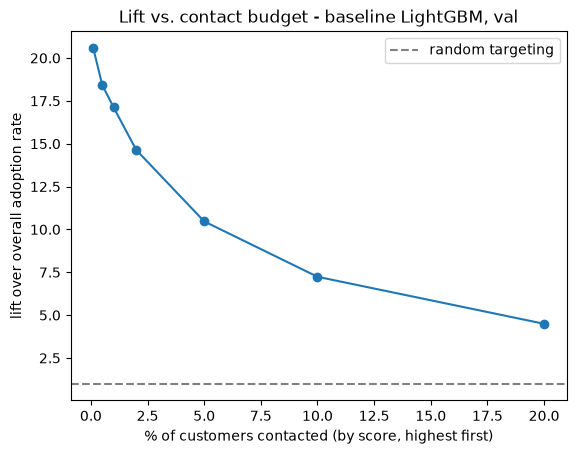

In [10]:
k_fracs = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
lifts = [top_k_lift(y_val, val_scores, k_frac=k) for k in k_fracs]

fig, ax = plt.subplots()
ax.plot([k * 100 for k in k_fracs], lifts, marker="o")
ax.axhline(1.0, linestyle="--", color="grey", label="random targeting")
ax.set_xlabel("% of customers contacted (by score, highest first)")
ax.set_ylabel("lift over overall adoption rate")
ax.set_title("Lift vs. contact budget - baseline LightGBM, val")
ax.legend()
plt.show()

### Takeaways

- ROC-AUC 0.915 (train) / 0.920 (val), top-1% lift 17.1x - a real, if
  modest, improvement over logistic regression's 0.906/0.912 and 14-17x
  lift, on the exact same features and split.
- `age_years` is the single most-split feature (292 of ~1,080 total
  splits), consistent with the non-monotonic per-bin lift pattern found in
  Phase 2 - and trees found it *without* the `age_years_sq` term LR needed
  (which still got some use - 27 splits - but wasn't essential).
  `tenure_months` and `product_count_prev` follow, matching both models'
  agreement on the strongest EDA signals.
- The class-reweighting finding above is the most important methodological
  result of this session: a fix that helps one model architecture (linear)
  doesn't automatically transfer to a structurally different one
  (sequential ensembles) - `best_iteration_` was what surfaced the problem,
  not the AUC number alone.
- Next: the formal precision@K evaluation - a fixed contact budget K,
  both models vs. random targeting, reported once on test - then
  `reports/02_baseline_model.md`.